<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000        

<Figure size 1200x800 with 0 Axes>

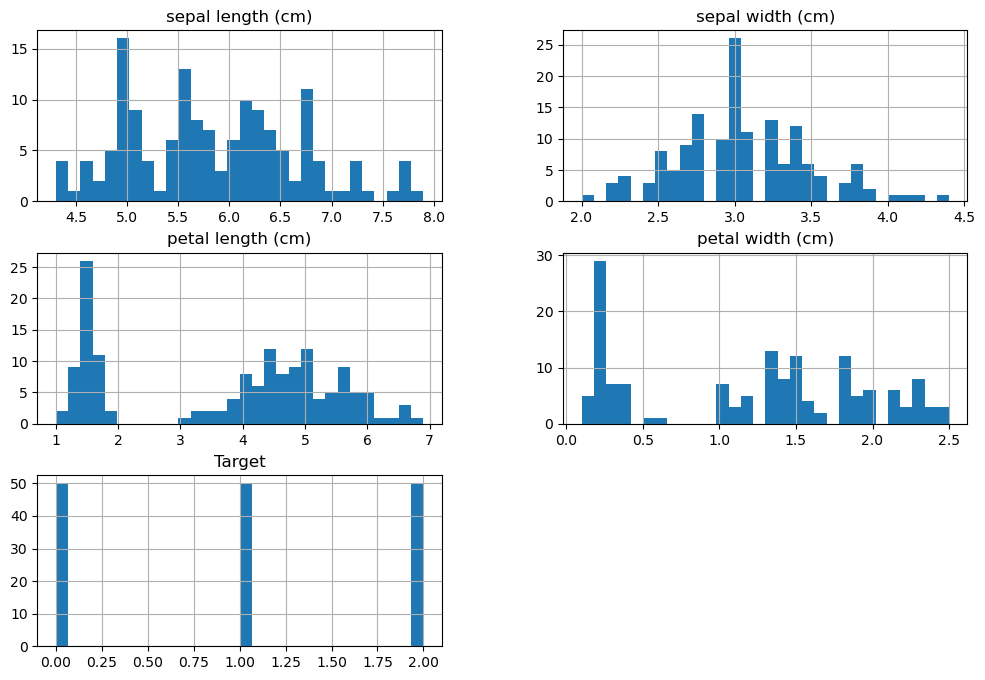

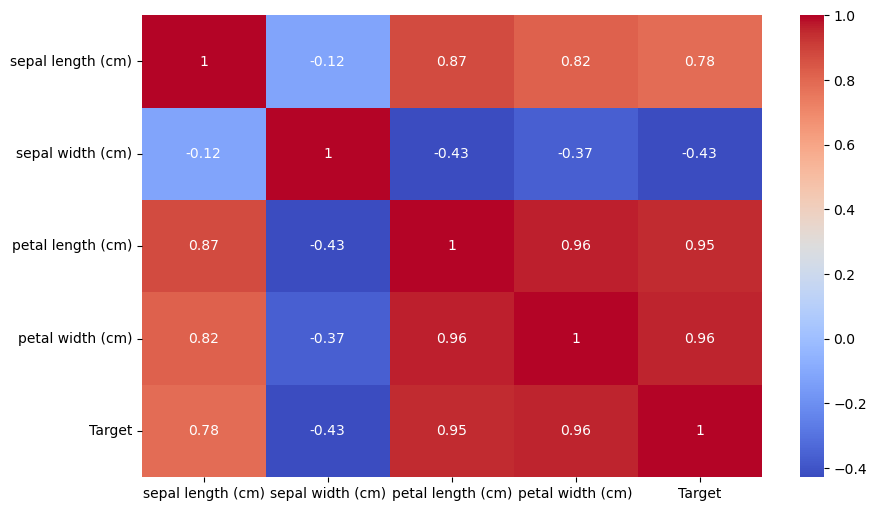

Epoch 1/50
4/4 [==============================] - 1s 81ms/step - loss: 0.9172 - accuracy: 0.6583 - val_loss: 0.8740 - val_accuracy: 0.7333
Epoch 2/50
4/4 [==============================] - 0s 18ms/step - loss: 0.8855 - accuracy: 0.6667 - val_loss: 0.8430 - val_accuracy: 0.7333
Epoch 3/50
4/4 [==============================] - 0s 20ms/step - loss: 0.8569 - accuracy: 0.6667 - val_loss: 0.8147 - val_accuracy: 0.7333
Epoch 4/50
4/4 [==============================] - 0s 23ms/step - loss: 0.8311 - accuracy: 0.6667 - val_loss: 0.7881 - val_accuracy: 0.7333
Epoch 5/50
4/4 [==============================] - 0s 18ms/step - loss: 0.8066 - accuracy: 0.6750 - val_loss: 0.7637 - val_accuracy: 0.7333
Epoch 6/50
4/4 [==============================] - 0s 17ms/step - loss: 0.7843 - accuracy: 0.6750 - val_loss: 0.7412 - val_accuracy: 0.7333
Epoch 7/50
4/4 [==============================] - 0s 16ms/step - loss: 0.7638 - accuracy: 0.6833 - val_loss: 0.7201 - val_accuracy: 0.7333
Epoch 8/50
4/4 [===========

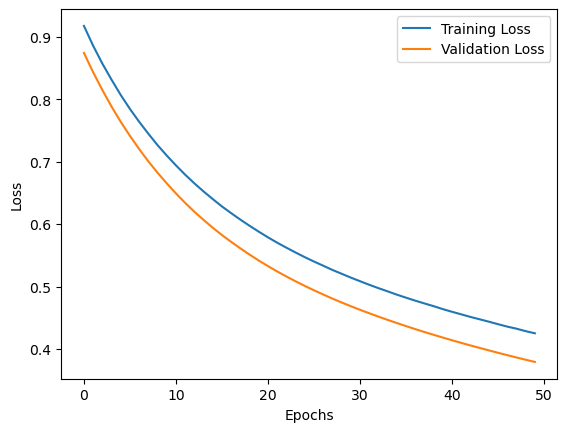

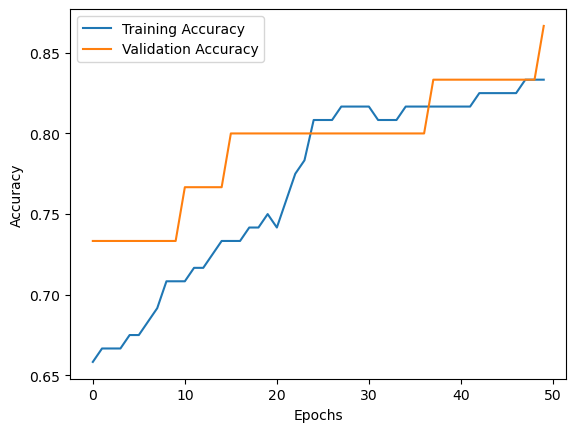

1/1 [==============================] - 0s 34ms/step - loss: 0.3793 - accuracy: 0.8667
Test Accuracy: 0.8666666746139526


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_iris

# Load the dataset
dataset = load_iris()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Encode target variable
y = keras.utils.to_categorical(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(y.shape[1], activation='softmax')  # Output layer for multiple classification
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000        

<Figure size 1200x800 with 0 Axes>

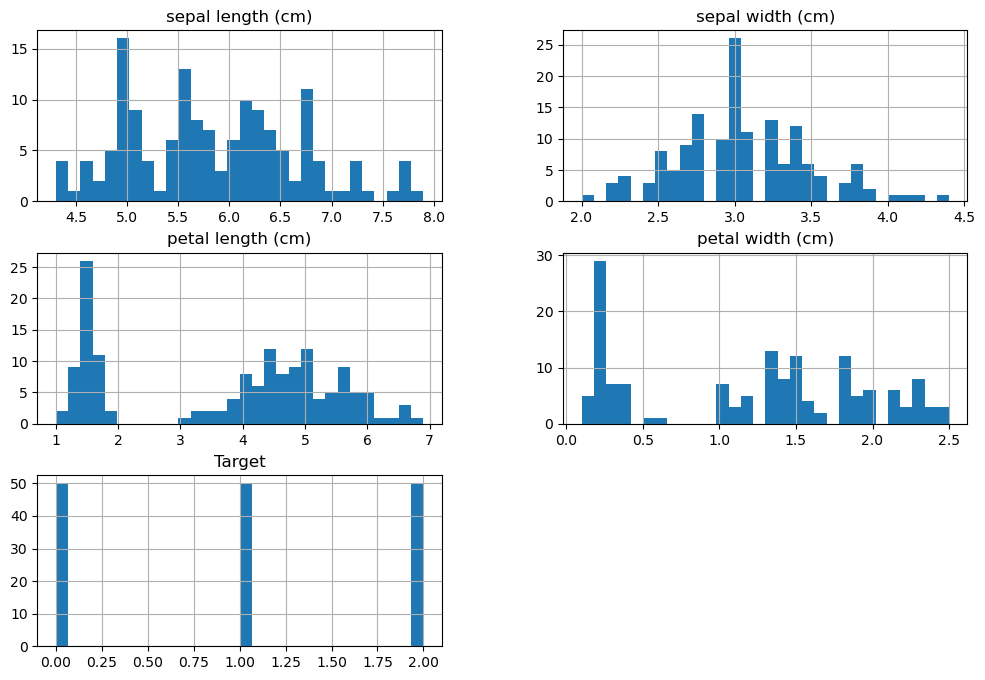

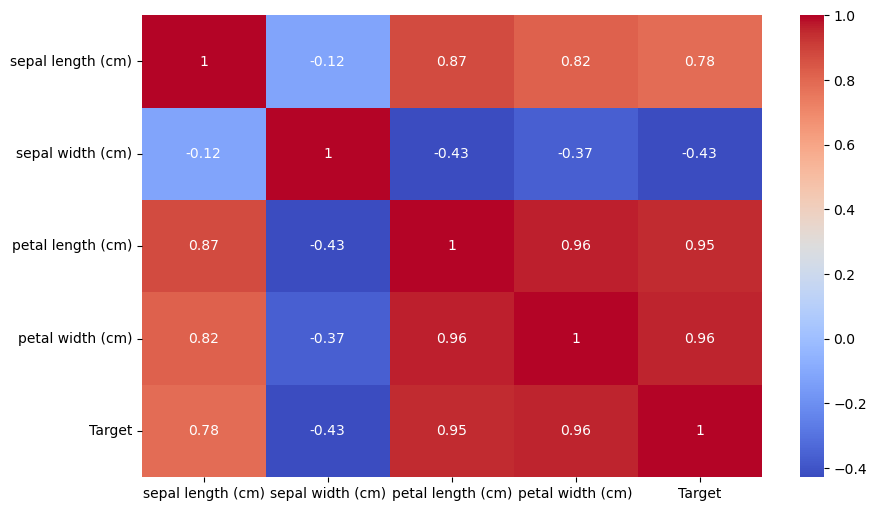

Epoch 1/50
4/4 [==============================] - 1s 83ms/step - loss: 0.7777 - accuracy: 0.6583 - val_loss: 0.7411 - val_accuracy: 0.7000
Epoch 2/50
4/4 [==============================] - 0s 22ms/step - loss: 0.7250 - accuracy: 0.6917 - val_loss: 0.6889 - val_accuracy: 0.7667
Epoch 3/50
4/4 [==============================] - 0s 18ms/step - loss: 0.6822 - accuracy: 0.7417 - val_loss: 0.6476 - val_accuracy: 0.8000
Epoch 4/50
4/4 [==============================] - 0s 17ms/step - loss: 0.6490 - accuracy: 0.7667 - val_loss: 0.6139 - val_accuracy: 0.8000
Epoch 5/50
4/4 [==============================] - 0s 18ms/step - loss: 0.6209 - accuracy: 0.7583 - val_loss: 0.5847 - val_accuracy: 0.9000
Epoch 6/50
4/4 [==============================] - 0s 18ms/step - loss: 0.5964 - accuracy: 0.7750 - val_loss: 0.5605 - val_accuracy: 0.9000
Epoch 7/50
4/4 [==============================] - 0s 17ms/step - loss: 0.5765 - accuracy: 0.8083 - val_loss: 0.5399 - val_accuracy: 0.8667
Epoch 8/50
4/4 [===========

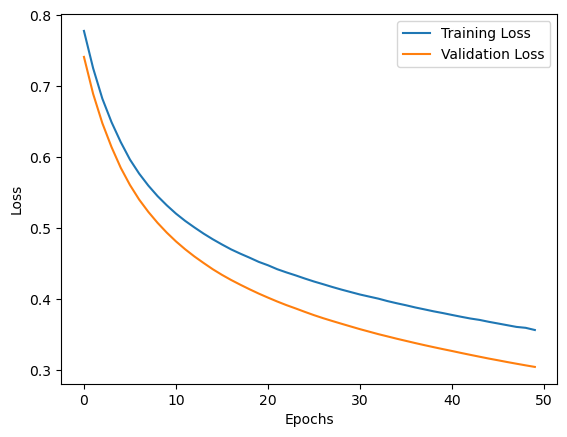

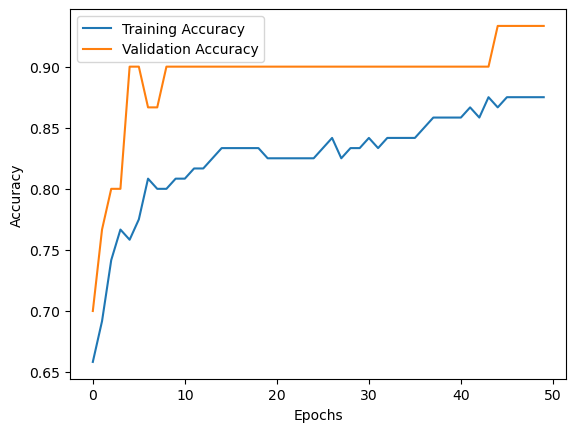

1/1 [==============================] - 0s 35ms/step - loss: 0.3040 - accuracy: 0.9333
Test Accuracy: 0.9333333373069763


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_iris

# Load the dataset
dataset = load_iris()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Encode target variable
y = keras.utils.to_categorical(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='tanh'),
    layers.Dense(y.shape[1], activation='softmax')  # Output layer for multiple classification
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000        

<Figure size 1200x800 with 0 Axes>

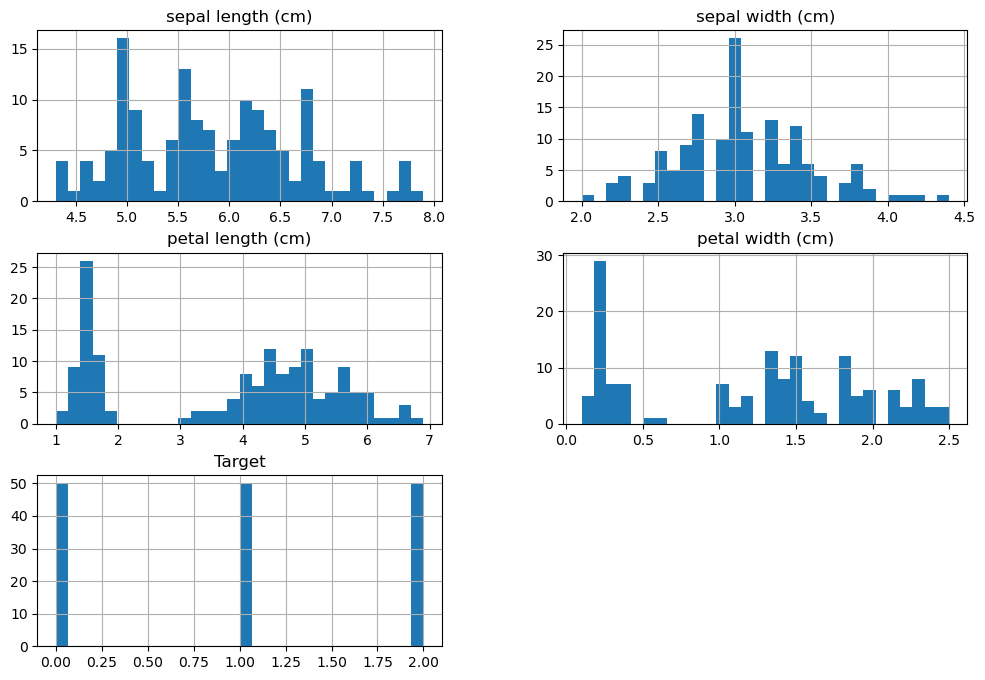

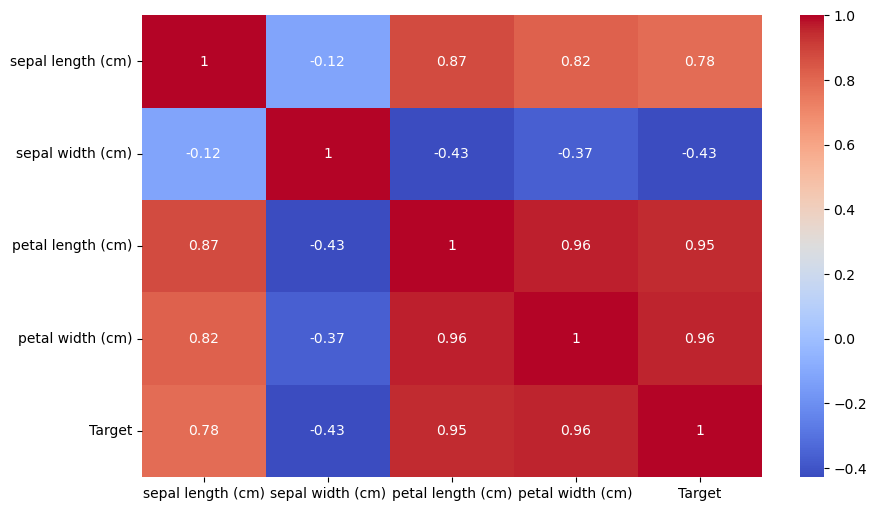

Epoch 1/50
4/4 [==============================] - 1s 84ms/step - loss: 0.8819 - accuracy: 0.5917 - val_loss: 0.5411 - val_accuracy: 0.9667
Epoch 2/50
4/4 [==============================] - 0s 21ms/step - loss: 0.4868 - accuracy: 0.8667 - val_loss: 0.3172 - val_accuracy: 0.9000
Epoch 3/50
4/4 [==============================] - 0s 29ms/step - loss: 0.3408 - accuracy: 0.8250 - val_loss: 0.2265 - val_accuracy: 0.9000
Epoch 4/50
4/4 [==============================] - 0s 21ms/step - loss: 0.2598 - accuracy: 0.8750 - val_loss: 0.1538 - val_accuracy: 0.9667
Epoch 5/50
4/4 [==============================] - 0s 23ms/step - loss: 0.2249 - accuracy: 0.9250 - val_loss: 0.1178 - val_accuracy: 0.9333
Epoch 6/50
4/4 [==============================] - 0s 19ms/step - loss: 0.1583 - accuracy: 0.9417 - val_loss: 0.0898 - val_accuracy: 1.0000
Epoch 7/50
4/4 [==============================] - 0s 25ms/step - loss: 0.1273 - accuracy: 0.9500 - val_loss: 0.0874 - val_accuracy: 0.9667
Epoch 8/50
4/4 [===========

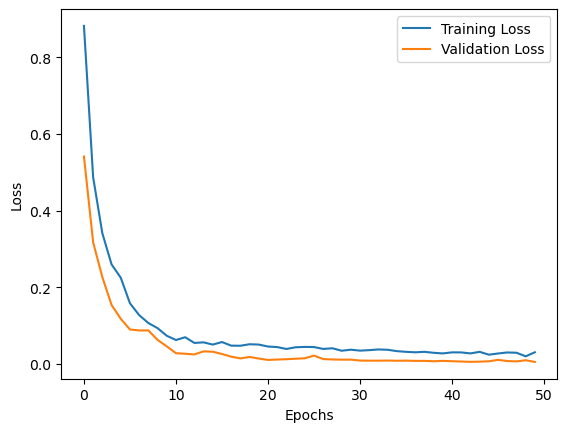

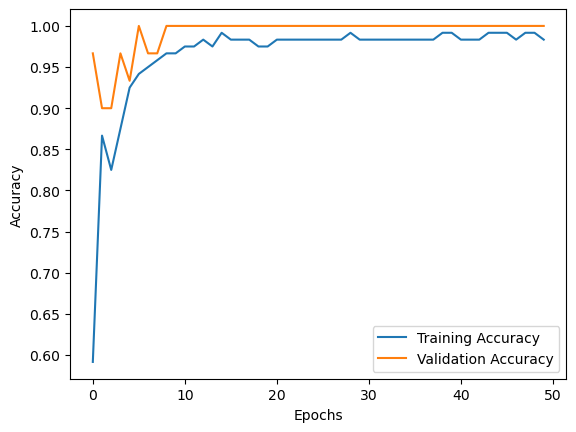

1/1 [==============================] - 0s 35ms/step - loss: 0.0053 - accuracy: 1.0000
Test Accuracy: 1.0


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_iris

# Load the dataset
dataset = load_iris()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Encode target variable
y = keras.utils.to_categorical(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(y.shape[1], activation='softmax')  # Output layer for multiple classification
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000        

<Figure size 1200x800 with 0 Axes>

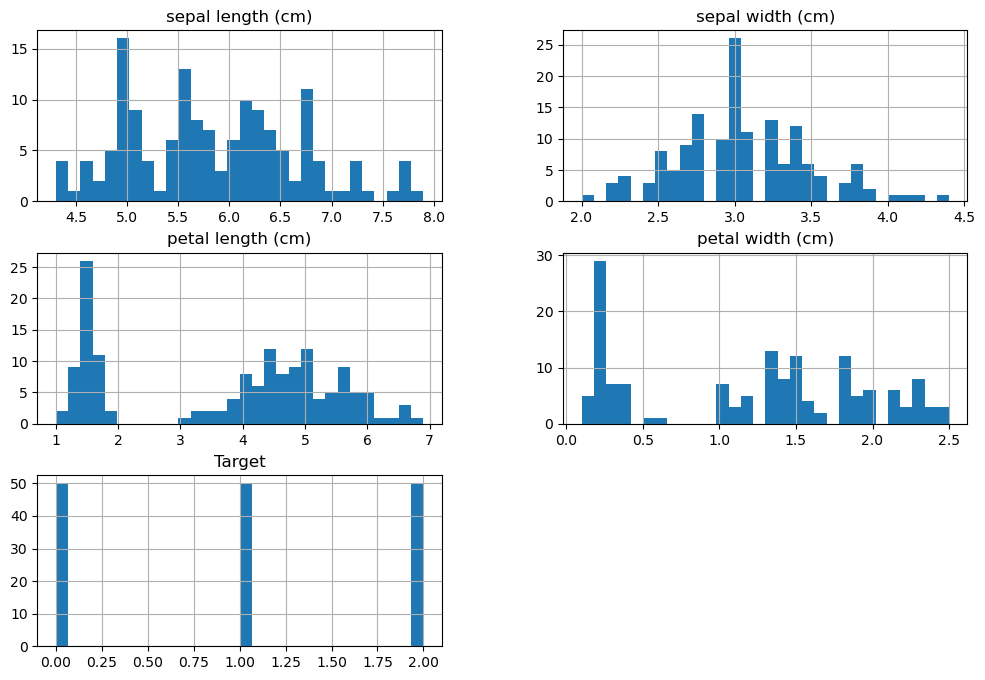

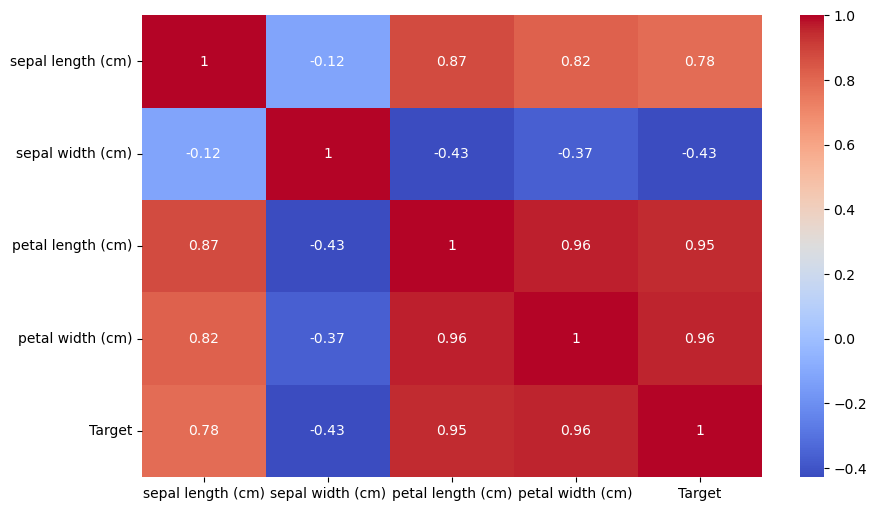

Epoch 1/50
4/4 [==============================] - 1s 82ms/step - loss: 1.3269 - accuracy: 0.3417 - val_loss: 1.3664 - val_accuracy: 0.3000
Epoch 2/50
4/4 [==============================] - 0s 18ms/step - loss: 1.2762 - accuracy: 0.3417 - val_loss: 1.3157 - val_accuracy: 0.3000
Epoch 3/50
4/4 [==============================] - 0s 17ms/step - loss: 1.2384 - accuracy: 0.3417 - val_loss: 1.2752 - val_accuracy: 0.3000
Epoch 4/50
4/4 [==============================] - 0s 19ms/step - loss: 1.2068 - accuracy: 0.3417 - val_loss: 1.2410 - val_accuracy: 0.3000
Epoch 5/50
4/4 [==============================] - 0s 17ms/step - loss: 1.1824 - accuracy: 0.3417 - val_loss: 1.2160 - val_accuracy: 0.3000
Epoch 6/50
4/4 [==============================] - 0s 17ms/step - loss: 1.1634 - accuracy: 0.3417 - val_loss: 1.1944 - val_accuracy: 0.3000
Epoch 7/50
4/4 [==============================] - 0s 16ms/step - loss: 1.1479 - accuracy: 0.3417 - val_loss: 1.1764 - val_accuracy: 0.3000
Epoch 8/50
4/4 [===========

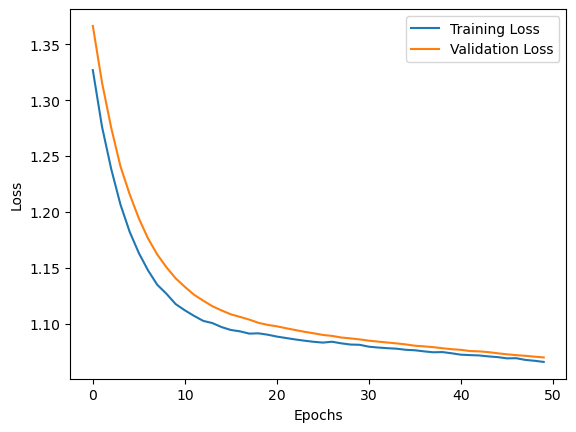

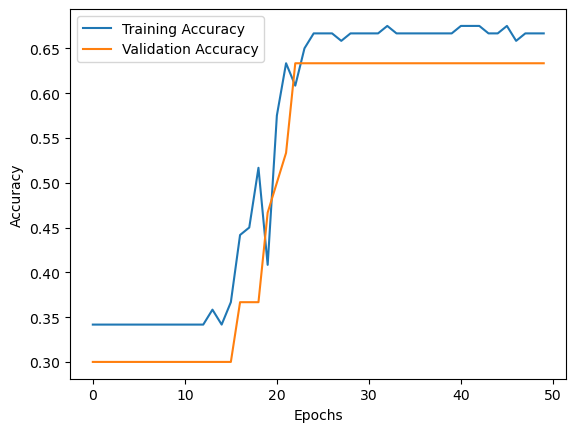

1/1 [==============================] - 0s 33ms/step - loss: 1.0701 - accuracy: 0.6333
Test Accuracy: 0.6333333253860474


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_iris

# Load the dataset
dataset = load_iris()
X, y = dataset.data, dataset.target  # Features and target
columns = dataset.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=columns)
df['Target'] = y

# Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

# Visualize feature distributions
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Encode target variable
y = keras.utils.to_categorical(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='sigmoid', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='sigmoid'),
    layers.Dense(y.shape[1], activation='softmax')  # Output layer for multiple classification
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy}')
